## 1) Objective

This notebook focuses on data quality checks for Instacart raw datasets:
- table-level quality overview
- missing values and duplicates
- key integrity across related tables
- basic data-rule validation and quick visual summaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
candidate_dirs = [Path('data/raw'), Path('../../data/raw')]
data_dir = next((p for p in candidate_dirs if p.exists()), None)
if data_dir is None:
    raise FileNotFoundError('Cannot find data/raw directory from current working directory.')

order_products_prior = pd.read_csv(data_dir / 'order_products__prior.csv')
order_products_train = pd.read_csv(data_dir / 'order_products__train.csv')
orders = pd.read_csv(data_dir / 'orders.csv')
products = pd.read_csv(data_dir / 'products.csv')
aisles = pd.read_csv(data_dir / 'aisles.csv')
departments = pd.read_csv(data_dir / 'departments.csv')

tables = {
    'orders': orders,
    'order_products_prior': order_products_prior,
    'order_products_train': order_products_train,
    'products': products,
    'aisles': aisles,
    'departments': departments,
}

print(f'Loaded {len(tables)} tables from: {data_dir.resolve()}')

Loaded 6 tables from: /home/ppt/Desktop/DataAnalyst/Instacart-Market-Basket-Analysis/data/raw


## 2) Table-Level Quality Overview

In [3]:
quality_overview = pd.DataFrame({
    'table': list(tables.keys()),
    'rows': [df.shape[0] for df in tables.values()],
    'cols': [df.shape[1] for df in tables.values()],
    'memory_mb': [round(df.memory_usage(deep=True).sum() / 1024**2, 2) for df in tables.values()],
    'duplicate_rows': [int(df.duplicated().sum()) for df in tables.values()],
    'missing_cells': [int(df.isna().sum().sum()) for df in tables.values()],
    'missing_pct_cells': [round((df.isna().sum().sum() / df.size) * 100, 4) for df in tables.values()],
}).sort_values('missing_cells', ascending=False)

quality_overview

,table,rows,cols,memory_mb,duplicate_rows,missing_cells,missing_pct_cells
0,orders,3421083,7,332.7100,0,206209,0.8611
1,order_products_prior,32434489,4,989.8200,0,0,0.0000
2,order_products_train,1384617,4,42.2600,0,0,0.0000
3,products,49688,4,4.9300,0,0,0.0000
4,aisles,134,2,0.0100,0,0,0.0000
5,departments,21,2,0.0000,0,0,0.0000


## 3) Missing Value Details

In [4]:
missing_by_column = (
    pd.concat(
        [
            pd.DataFrame({
                'table': name,
                'column': df.columns,
                'missing_count': df.isna().sum().values,
                'missing_pct': (df.isna().mean() * 100).values,
            })
            for name, df in tables.items()
        ],
        ignore_index=True,
    )
    .query('missing_count > 0')
    .sort_values(['missing_pct', 'missing_count'], ascending=False)
)

missing_by_column.head(20)

,table,column,missing_count,missing_pct
6,orders,days_since_prior_order,206209,6.0276


## 4) Key Integrity and Duplicates

In [5]:
integrity = {
    'orders.order_id_unique': orders['order_id'].is_unique,
    'products.product_id_unique': products['product_id'].is_unique,
    'aisles.aisle_id_unique': aisles['aisle_id'].is_unique,
    'departments.department_id_unique': departments['department_id'].is_unique,
    'order_products_prior(order_id, product_id) duplicated': int(order_products_prior.duplicated(['order_id', 'product_id']).sum()),
    'order_products_train(order_id, product_id) duplicated': int(order_products_train.duplicated(['order_id', 'product_id']).sum()),
    'prior.order_id_in_orders_pct': round(order_products_prior['order_id'].isin(orders['order_id']).mean() * 100, 3),
    'train.order_id_in_orders_pct': round(order_products_train['order_id'].isin(orders['order_id']).mean() * 100, 3),
    'prior.product_id_in_products_pct': round(order_products_prior['product_id'].isin(products['product_id']).mean() * 100, 3),
    'train.product_id_in_products_pct': round(order_products_train['product_id'].isin(products['product_id']).mean() * 100, 3),
}

pd.Series(integrity, name='result')

orders.order_id_unique                                      True
products.product_id_unique                                  True
aisles.aisle_id_unique                                      True
departments.department_id_unique                            True
order_products_prior(order_id, product_id) duplicated          0
order_products_train(order_id, product_id) duplicated          0
prior.order_id_in_orders_pct                            100.0000
train.order_id_in_orders_pct                            100.0000
prior.product_id_in_products_pct                        100.0000
train.product_id_in_products_pct                        100.0000
Name: result, dtype: object

## 5) Data Rule Validation
Check whether important columns follow expected ranges and allowed values.

In [6]:
rules = {
    'orders.order_dow_invalid_count': int((~orders['order_dow'].between(0, 6)).sum()),
    'orders.order_hour_of_day_invalid_count': int((~orders['order_hour_of_day'].between(0, 23)).sum()),
    'orders.order_number_lt_1_count': int((orders['order_number'] < 1).sum()),
    'orders.days_since_prior_order_negative_count': int((orders['days_since_prior_order'] < 0).sum()),
    'prior.add_to_cart_order_lt_1_count': int((order_products_prior['add_to_cart_order'] < 1).sum()),
    'train.add_to_cart_order_lt_1_count': int((order_products_train['add_to_cart_order'] < 1).sum()),
    'prior.reordered_not_binary_count': int((~order_products_prior['reordered'].isin([0, 1])).sum()),
    'train.reordered_not_binary_count': int((~order_products_train['reordered'].isin([0, 1])).sum()),
}

pd.Series(rules, name='invalid_count')

orders.order_dow_invalid_count                  0
orders.order_hour_of_day_invalid_count          0
orders.order_number_lt_1_count                  0
orders.days_since_prior_order_negative_count    0
prior.add_to_cart_order_lt_1_count              0
train.add_to_cart_order_lt_1_count              0
prior.reordered_not_binary_count                0
train.reordered_not_binary_count                0
Name: invalid_count, dtype: int64

## 6) Quick Quality Plots

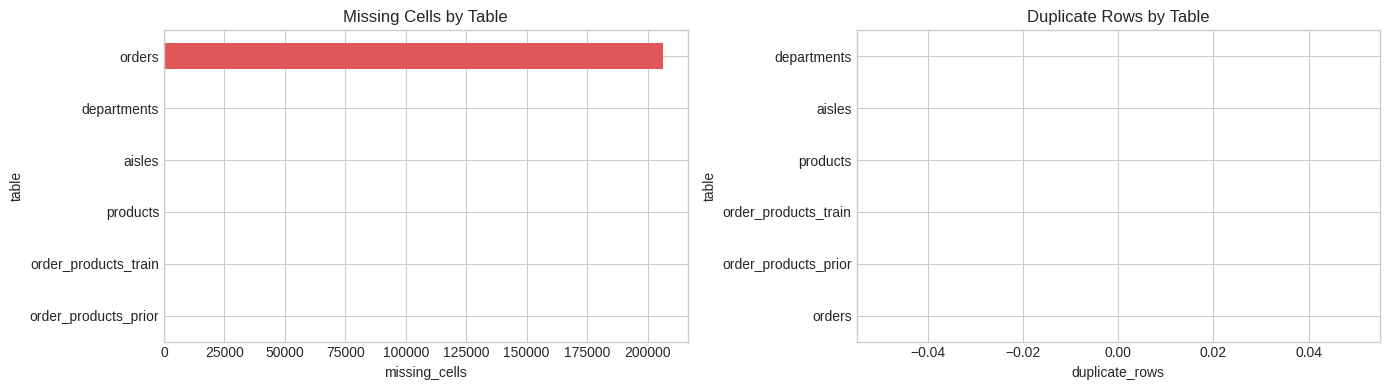

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

quality_overview.sort_values('missing_cells', ascending=True).plot(
    x='table', y='missing_cells', kind='barh', ax=axes[0], color='#E15759', legend=False
)
axes[0].set_title('Missing Cells by Table')
axes[0].set_xlabel('missing_cells')
axes[0].set_ylabel('table')

quality_overview.sort_values('duplicate_rows', ascending=True).plot(
    x='table', y='duplicate_rows', kind='barh', ax=axes[1], color='#4E79A7', legend=False
)
axes[1].set_title('Duplicate Rows by Table')
axes[1].set_xlabel('duplicate_rows')
axes[1].set_ylabel('table')

plt.tight_layout()
plt.show()

## 7) Findings and Next Actions
After running all checks, summarize in 4-6 bullets:
- highest-risk quality issue
- where missing values are concentrated
- key integrity status
- any violated data rules
- action plan before data preparation